In [18]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append('../')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
from src.data_loader import fetch_and_encode_nsrdb_data

df = fetch_and_encode_nsrdb_data(lat=26, lon=-80, year=2022)
display(df.head())

Fetching NSRDB data for Lat: 26, Lon: -80, Year: 2022...
API data successfully fetched and temporally encoded.


,expected_power_output,DHI,DNI,Wind Speed,Temperature,Relative Humidity,hour_sin,hour_cos,day_sin,day_cos
0,0,0,0,4.7,24.2,85.16,0.000000,1.000000,0.017213,0.999852
1,0,0,0,4.7,24.1,86.70,0.258819,0.965926,0.017213,0.999852
2,0,0,0,4.5,23.9,88.14,0.500000,0.866025,0.017213,0.999852
3,0,0,0,4.4,23.9,87.61,0.707107,0.707107,0.017213,0.999852
4,0,0,0,4.3,23.9,86.54,0.866025,0.500000,0.017213,0.999852


In [20]:
from src.preprocessing import Z_Standardization
import numpy as np

X_scaled, y, mu, sigma = Z_Standardization(df)

# Tells you the dimension of the matrix
print(f"Shape of X_scaled (Features): {X_scaled.shape}")

print(f"Shape of y (Target): {y.shape}")

print(f"Mean of the first feature column (should be ~0): {np.mean(X_scaled[:, 0]):.5f}")

print(f"Std Dev of the first feature column (should be 1): {np.std(X_scaled[:, 0]):.5f}")

Shape of X_scaled (Features): (8760, 9)
Shape of y (Target): (8760,)
Mean of the first feature column (should be ~0): -0.00000
Std Dev of the first feature column (should be 1): 1.00000


In [21]:
from src.preprocessing import bias_column, initialize_weights


X_final = bias_column(X_scaled)

w_initial =  initialize_weights(X_final.shape[1])

print(f"Old X shape: {X_scaled.shape}")
print(f"New X shape: {X_final.shape}")
print(f"Weight vector shape: {w_initial.shape}")
print(f"First row of X_final: {X_final[0, :5]}")

Old X shape: (8760, 9)
New X shape: (8760, 10)
Weight vector shape: (10,)
First row of X_final: [ 1.         -0.75922507 -0.72022408  0.31314543 -0.63435978]


Initializing the Custom Linear Regression Engine...
Training the Model on X_train...
Epoch    0 | MSE Loss: 57604.6585
Epoch  100 | MSE Loss: 6233.2643
Epoch  200 | MSE Loss: 6215.4028
Epoch  300 | MSE Loss: 6215.2500
Epoch  400 | MSE Loss: 6215.2487
Generating Predictions for X_test...

--- FINAL OOP GRADES ---
Training MSE (from model memory): 6215.2487
Testing MSE  (on unseen data):    5149.1967



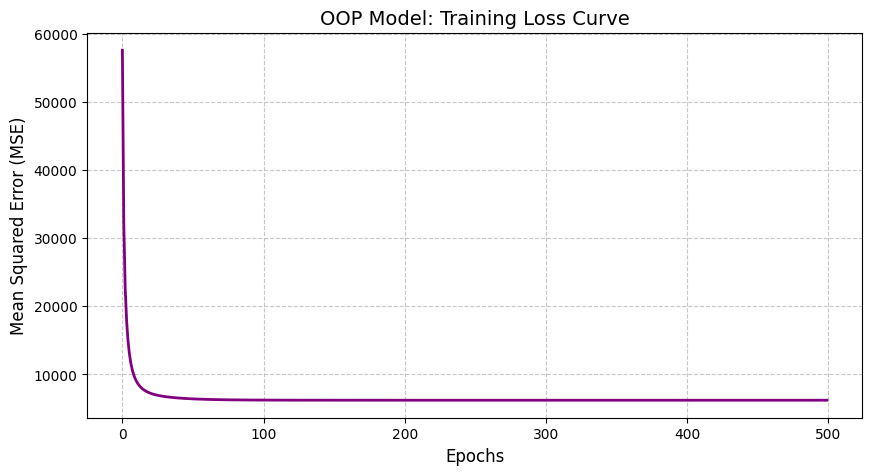

In [24]:
from src.model import CustomLinearRegression
import matplotlib.pyplot as plt
import numpy as np

print("Initializing the Custom Linear Regression Engine...")
model = CustomLinearRegression(learning_rate=0.1, epochs=500)

print("Training the Model on X_train...")
model.fit(X_train, y_train)

print("Generating Predictions for X_test...")
predictions = model.predict(X_test)

test_mse = np.mean(np.square(predictions - y_test))

print(f"\n--- FINAL OOP GRADES ---")
print(f"Training MSE (from model memory): {model.loss_history[-1]:.4f}")
print(f"Testing MSE  (on unseen data):    {test_mse:.4f}\n")

plt.figure(figsize=(10, 5))
plt.plot(model.loss_history, color='purple', linewidth=2)
plt.title("OOP Model: Training Loss Curve", fontsize=14)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Mean Squared Error (MSE)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

FINAL R-SQUARED SCORE: 90.25%



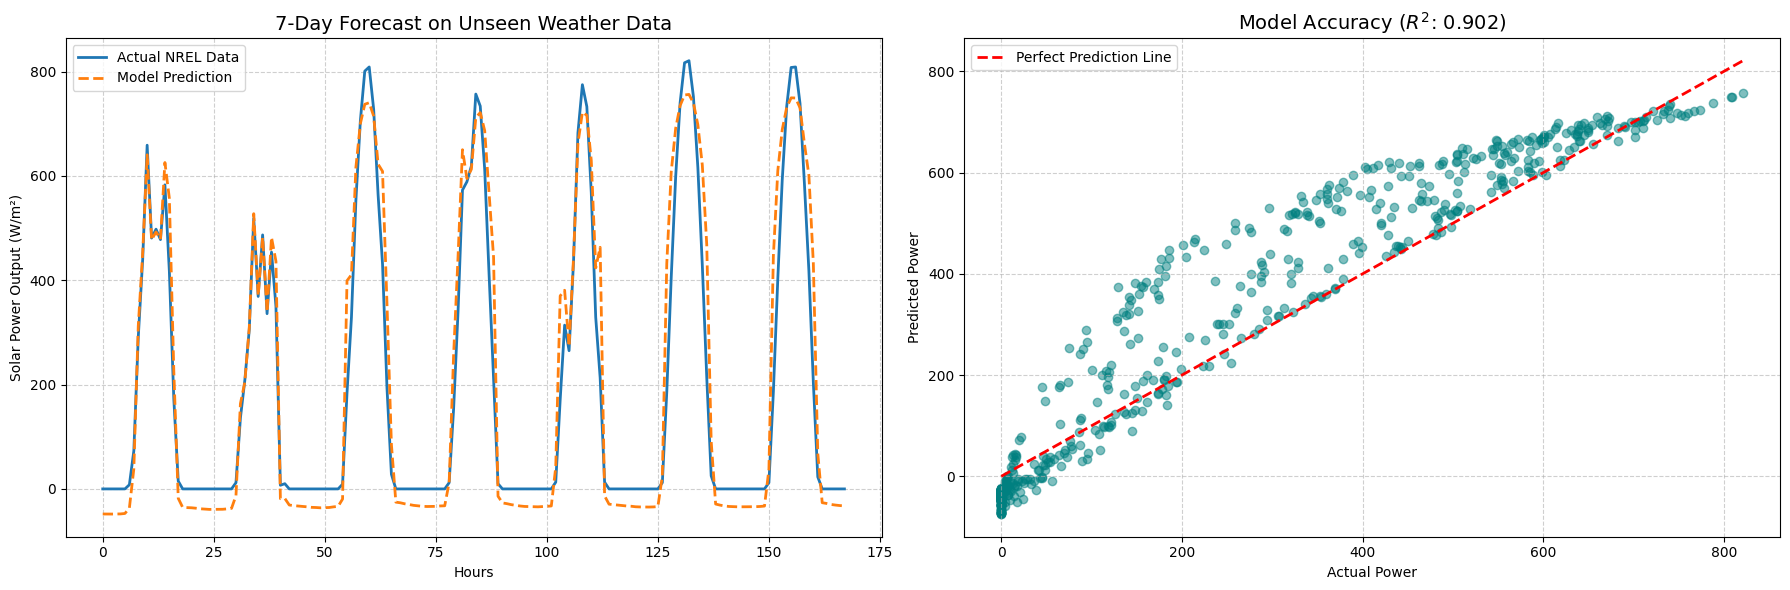

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Generate final predictions
y_pred_test = model.predict(X_test)

# Calculating the R-Squared Score
ss_total = np.sum(np.square(y_test - np.mean(y_test)))
ss_residual = np.sum(np.square(y_test - y_pred_test))
r2_score = 1 - (ss_residual / ss_total)

print(f"FINAL R-SQUARED SCORE: {r2_score * 100:.2f}%\n")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# The 7-Day Time Series Overlay 
window = 168 # 7 days
axes[0].plot(y_test[:window], label='Actual NREL Data', color='#1f77b4', linewidth=2)
axes[0].plot(y_pred_test[:window], label='Model Prediction', color='#ff7f0e', linestyle='--', linewidth=2)
axes[0].set_title("7-Day Forecast on Unseen Weather Data", fontsize=14)
axes[0].set_ylabel("Solar Power Output (W/m²)")
axes[0].set_xlabel("Hours")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# The Scatter Plot (Actual vs Predicted) 
sample_indices = np.random.choice(len(y_test), 1000, replace=False)
axes[1].scatter(y_test[sample_indices], y_pred_test[sample_indices], alpha=0.5, color='teal')

max_val = max(np.max(y_test), np.max(y_pred_test))
axes[1].plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction Line')

axes[1].set_title(f"Model Accuracy ($R^2$: {r2_score:.3f})", fontsize=14)
axes[1].set_xlabel("Actual Power")
axes[1].set_ylabel("Predicted Power")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()